# =============================================================================
# 03_TOPICS_POLARIZATION.IPYNB
# Modelare Tematică cu BERTopic
# 
# Disertație de Master - Facultatea de Sociologie și Asistență Socială, UBB Cluj-Napoca
# Master: Analiza Datelor Complexe
# Masterand: Răzvan-Andrei Enache
# =============================================================================

# 1. Import Configurări și Librării

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from config import *

# Pentru BERTopic
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

print("✅ Librării încărcate cu succes.")

✅ CONFIGURARE GLOBALĂ ÎNCĂRCATĂ CU SUCCES

📁 Baza de date: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data
📂 Raw data: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\data\raw
📂 Processed: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\data\processed
📂 Output: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\dissertation_outputs

📅 Perioadă electorală: 2025-05-01 până la 2025-05-18
🔑 Keywords Simion: 4
🔑 Keywords Nicușor: 5
🤖 Model RoBERTa: readerbench/ro-sentiment
📊 Nivel de semnificație: α = 0.05


✅ Librării încărcate cu succes.


# 2. Încărcare Date Analizate

In [2]:
print("=" * 70)
print("ÎNCĂRCARE DATE ANALIZATE")
print("=" * 70)

if not FILE_COMMENTS_ANALYZED.exists():
    raise FileNotFoundError(f"Fișierul analizat nu a fost găsit: {FILE_COMMENTS_ANALYZED}")

print(f"\n📁 Fișier: {FILE_COMMENTS_ANALYZED}")
print("\n⏳ Se încarcă datele...")

df = pd.read_csv(FILE_COMMENTS_ANALYZED, parse_dates=['comment_date'])

print(f"\n✅ Date încărcate cu succes!")
print(f"   Comentarii: {len(df):,} rânduri")
print(f"   Coloane: {df.shape[1]}")

# Filter to political comments only
df_political = df[df['candidate_mentioned'].isin(['dan', 'simion'])].copy()
print(f"\n📊 Comentarii politice (Dan/Simion): {len(df_political):,}")

# Check if we have enough data
if len(df_political) < 100:
    print(f"\n⚠️  ATENȚIE: Doar {len(df_political)} comentarii politice!")
    print("   BERTopic necesită minim 100 de documente pentru topic modeling.")

ÎNCĂRCARE DATE ANALIZATE

📁 Fișier: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\data\processed\comments_analyzed.csv

⏳ Se încarcă datele...

✅ Date încărcate cu succes!
   Comentarii: 14,610 rânduri
   Coloane: 28

📊 Comentarii politice (Dan/Simion): 5,168


# 3. BERTopic - Configurare și Rulare

In [ ]:
print("\n" + "=" * 70)
print("BERTOPIC - CONFIGURARE")
print("=" * 70)

print("\n🤖 Configurare BERTopic cu embeddings românești...")
print("   Model: readerbench/RoBERT-base (românesc, NU multilingual)")

# =============================================================================
# PREPROCESSARE TEXT PENTRU BERTOPIC (REMOVE STOPWORDS!)
# =============================================================================
print("\n📝 Preprocesare text - remove stopwords românești...")

df_political['text_for_bertopic'] = df_political['clean_text'].apply(
    lambda x: remove_stopwords_romanian(x, ROMANIAN_STOPWORDS)
)

# Prepare documents - folosim textul FĂRĂ stopwords
documents = df_political['text_for_bertopic'].fillna('').astype(str).tolist()

# Filtrăm documentele goale după remove stopwords
non_empty_docs = [(i, doc) for i, doc in enumerate(documents) if len(doc.strip()) > 0]
doc_indices = [i for i, doc in non_empty_docs]
documents_filtered = [doc for i, doc in non_empty_docs]

print(f"   Documente inițiale: {len(documents):,}")
print(f"   Documente după filtrare: {len(documents_filtered):,}")
print(f"   Documente eliminate (goale): {len(documents) - len(documents_filtered):,}")

# Încarcă embeddings românești
print("\n🤖 Încărcare embeddings românești (poate dura 1-2 minute)...")
embedding_model = SentenceTransformer(BERTOPIC_EMBEDDING_MODEL)
print(f"   ✅ Embeddings încărcate: {BERTOPIC_EMBEDDING_MODEL}")

# =============================================================================
# CONFIGURARE BERTOPIC CU STOPWORDS
# =============================================================================
print("\n📋 Configurare BERTopic:")
print(f"   Embeddings: {BERTOPIC_EMBEDDING_MODEL} (românesc)")
print(f"   Min topic size: {BERTOPIC_MIN_TOPIC_SIZE}")
print(f"   Top N words: {BERTOPIC_TOP_N_WORDS}")
print(f"   Reduce topics: auto")
print(f"   Stopwords: românești (din config.py)")

topic_model = BERTopic(
    embedding_model=embedding_model,
    language=None,  # Nu setăm când avem embeddings custom
    min_topic_size=BERTOPIC_MIN_TOPIC_SIZE,
    top_n_words=BERTOPIC_TOP_N_WORDS,
    nr_topics=BERTOPIC_N_TOPICS,
    calculate_probabilities=True,
    verbose=True
)

# Fit model
print("\n⏳ Rulare BERTopic (poate dura 10-30 minute pe CPU)...")
topics, probs = topic_model.fit_transform(documents_filtered)

print(f"\n✅ BERTopic completat!")
print(f"   Topics identificate: {len(set(topics)) - 1}")

# =============================================================================
# ADAUGĂ TOPICS LA DATAFRAME (vectorizat)
# =============================================================================
df_political['topic'] = -1  # Default -1 pentru toate
df_political['topic_probability'] = 0.0

# Assign topics vectorizat (mai rapid decât loop)
df_political.loc[df_political.index[doc_indices], 'topic'] = topics
df_political.loc[df_political.index[doc_indices], 'topic_probability'] = [
    max(prob) if prob is not None else 0.0 for prob in probs
]

print(f"   Topics assignate la {len(doc_indices):,} comentarii")



BERTOPIC - CONFIGURARE

🤖 Configurare BERTopic cu embeddings românești...
   Model: readerbench/RoBERT-base (românesc, NU multilingual)

📝 Preprocesare text - remove stopwords românești...
   Documente inițiale: 5,168
   Documente după filtrare: 5,168
   Documente eliminate (goale): 0

🤖 Încărcare embeddings românești (poate dura 1-2 minute)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9181.64it/s]
[transformers] BertModel LOAD REPORT from: readerbench/RoBERT-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-06-07 22:54:06,926 - BERTopic - Embedding - Transforming

   ✅ Embeddings încărcate: readerbench/RoBERT-base

📋 Configurare BERTopic:
   Embeddings: readerbench/RoBERT-base (românesc)
   Min topic size: 10
   Top N words: 10
   Reduce topics: auto
   Stopwords: românești (din config.py)

⏳ Rulare BERTopic (poate dura 10-30 minute pe CPU)...


Batches: 100%|██████████| 162/162 [07:35<00:00,  2.81s/it]
2026-06-07 23:01:42,903 - BERTopic - Embedding - Completed ✓
2026-06-07 23:01:42,924 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-07 23:02:37,561 - BERTopic - Dimensionality - Completed ✓
2026-06-07 23:02:37,565 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-07 23:02:38,758 - BERTopic - Cluster - Completed ✓
2026-06-07 23:02:38,787 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-07 23:02:39,059 - BERTopic - Representation - Completed ✓



✅ BERTopic completat!
   Topics identificate: 36
   Topics assignate la 5,168 comentarii


# 4. Analiza Topic-urilor pe Candidați

In [ ]:
print("\n" + "=" * 70)
print("ANALIZA TOPIC-URILOR PE CANDIDAȚI")
print("=" * 70)

# Get topic info
topic_info = topic_model.get_topic_info()
print("\n📊 Topic Info:")
print(topic_info.to_string())

# Separate topics by candidate
print("\n📊 Distribuție topic-uri pe candidați:")

dan_docs = df_political[df_political['candidate_mentioned'] == 'dan']['text_for_bertopic'].tolist()
simion_docs = df_political[df_political['candidate_mentioned'] == 'simion']['text_for_bertopic'].tolist()

print(f"   Dan: {len(dan_docs):,} comentarii")
print(f"   Simion: {len(simion_docs):,} comentarii")



ANALIZA TOPIC-URILOR PE CANDIDAȚI

📊 Topic Info:
    Topic  Count                                         Name                                                                                           Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

# 5. Sentiment pe Topic-uri


SENTIMENT PE TOPIC-URI

📊 Sentiment Mediu pe Topic:
           sentiment_score               candidate_mentioned
                      mean     std count               first
topic_name                                                  
Outlier             0.7301  0.1382  1707              simion
ales                0.6422  0.1007    11              simion
convins             0.7685  0.1657    15                 dan
cra                 0.9082  0.1121    13              simion
dezbateri           0.7154  0.1325    20              simion
doamne              0.7877  0.1470    17              simion
ferească            0.8208  0.1000    11                 dan
fără                0.6766  0.1085    47              simion
george              0.7640  0.1631   137              simion
ministru            0.6687  0.1084    14              simion
minte               0.6100  0.1057    13              simion
mucușor             0.7069  0.1414    14              simion
nicusor             0.7343  0.13

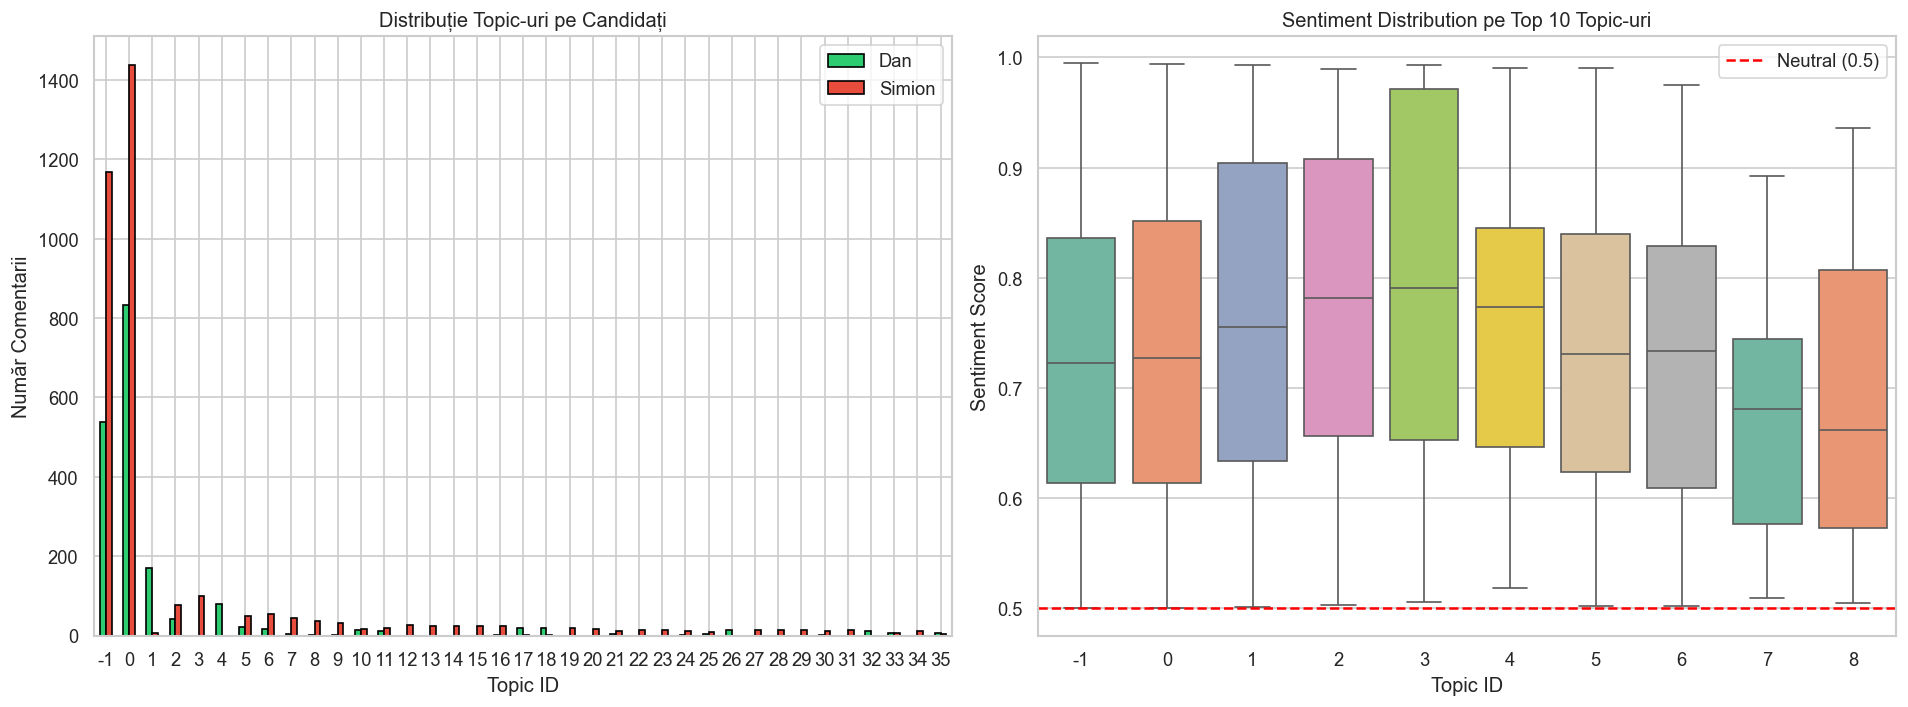

In [9]:
print("\n" + "=" * 70)
print("SENTIMENT PE TOPIC-URI")
print("=" * 70)

# Merge topic info with sentiment
df_with_topics = df_political.copy()
df_with_topics['topic_name'] = df_with_topics['topic'].apply(
    lambda x: topic_model.get_topic(x)[0][0] if x != -1 else 'Outlier'
)

# Calculate sentiment by topic
sentiment_by_topic = df_with_topics.groupby('topic_name').agg({
    'sentiment_score': ['mean', 'std', 'count'],
    'candidate_mentioned': 'first'
}).round(4)

print("\n📊 Sentiment Mediu pe Topic:")
print(sentiment_by_topic.head(40).to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Topic distribution by candidate
topic_cand_cross = pd.crosstab(df_political['topic'], df_political['candidate_mentioned'])
topic_cand_cross.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_xlabel('Topic ID')
axes[0].set_ylabel('Număr Comentarii')
axes[0].set_title('Distribuție Topic-uri pe Candidați')
axes[0].legend(['Dan', 'Simion'])
axes[0].tick_params(axis='x', rotation=0)

# Sentiment by topic
top_topics = df_political['topic'].value_counts().head(10).index
df_top = df_political[df_political['topic'].isin(top_topics)]
sns.boxplot(data=df_top, x='topic', y='sentiment_score', ax=axes[1], palette='Set2')
axes[1].set_xlabel('Topic ID')
axes[1].set_ylabel('Sentiment Score')
axes[1].set_title('Sentiment Distribution pe Top 10 Topic-uri')
axes[1].axhline(0.5, color='red', linestyle='--', label='Neutral (0.5)')
axes[1].legend()

plt.tight_layout()
plt.savefig(DATA_OUTPUT / 'rq2_topics_analysis.png', dpi=150, bbox_inches='tight')
print(f"\n💾 Grafic salvat: {DATA_OUTPUT / 'rq2_topics_analysis.png'}")
plt.show()

# 6. Export Tabele pentru Disertație

In [10]:
print("\n" + "=" * 70)
print("EXPORT TABELE PENTRU DISERTAȚIE")
print("=" * 70)

# Table: Top Topics by Candidate
table_topics = []
for cand in ['dan', 'simion']:
    cand_topics = df_political[df_political['candidate_mentioned'] == cand]['topic'].value_counts().head(5)
    for topic_id, count in cand_topics.items():
        if topic_id != -1:
            topic_words = topic_model.get_topic(topic_id)
            table_topics.append({
                'Candidat': 'Nicușor Dan' if cand == 'dan' else 'George Simion',
                'Topic ID': topic_id,
                'Count': count,
                'Top Words': ', '.join([w[0] for w in topic_words[:5]]),
                'Avg Sentiment': df_political[df_political['topic'] == topic_id]['sentiment_score'].mean()
            })

table_topics_df = pd.DataFrame(table_topics)
table_topics_df.to_csv(DATA_OUTPUT / 'table_4_topics_by_candidate.csv', index=False, encoding='utf-8-sig')
print(f"✅ Tabel topic-uri exportat: {DATA_OUTPUT / 'table_4_topics_by_candidate.csv'}")

# Save topic model
topic_model.save(f"{DATA_PROCESSED}/bertopic_model", serialization="safetensors")
print(f"✅ Model BERTopic salvat: {DATA_PROCESSED}/bertopic_model")

# Save analyzed data with topics
df_political.to_csv(DATA_PROCESSED / 'comments_with_topics.csv', index=False, encoding='utf-8-sig')
print(f"✅ Date cu topic-uri exportate: {DATA_PROCESSED / 'comments_with_topics.csv'}")



EXPORT TABELE PENTRU DISERTAȚIE
✅ Tabel topic-uri exportat: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\dissertation_outputs\table_4_topics_by_candidate.csv
✅ Model BERTopic salvat: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\data\processed/bertopic_model
✅ Date cu topic-uri exportate: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\data\processed\comments_with_topics.csv


# 7. Rezumat RQ2 (Extensie Tematică)

In [7]:
print("\n" + "=" * 70)
print("REZUMAT RQ2 - ANALIZĂ TEMATICĂ")
print("=" * 70)

# Calculează topicuri pe candidați (dacă nu sunt deja calculate)
if 'dan_topics' not in locals():
    dan_topics = df_political[df_political['candidate_mentioned'] == 'dan']['topic'].value_counts().head(5)
    simion_topics = df_political[df_political['candidate_mentioned'] == 'simion']['topic'].value_counts().head(5)

# Numără topic-uri unice (excluzând outlier -1)
n_topics = len(set(topics)) - 1 if -1 in set(topics) else len(set(topics))

print(f"""
╔══════════════════════════════════════════════════════════════════════════╗
║                    REZUMAT MODELARE TEMATICĂ (BERTopic)                  ║
╠══════════════════════════════════════════════════════════════════════════╣
║ Total comentarii analizate: {len(df_political):>10,}                                ║
║ Topic-uri identificate:     {n_topics:>10} (excluzând outlier)              ║
╠══════════════════════════════════════════════════════════════════════════╣
║ DAN - Tema Dominantă:                                                     ║
║   • Topic ID: {dan_topics.index[0] if len(dan_topics) > 0 and dan_topics.index[0] != -1 else 'N/A':>5}                         ║
║   • Comentarii: {dan_topics.iloc[0] if len(dan_topics) > 0 else 'N/A':>8,}                              ║
╠══════════════════════════════════════════════════════════════════════════╣
║ SIMION - Tema Dominantă:                                                  ║
║   • Topic ID: {simion_topics.index[0] if len(simion_topics) > 0 and simion_topics.index[0] != -1 else 'N/A':>5}                         ║
║   • Comentarii: {simion_topics.iloc[0] if len(simion_topics) > 0 else 'N/A':>8,}                              ║
╚══════════════════════════════════════════════════════════════════════════╝

📁 FIȘIERE EXPORTATE:
   • {DATA_OUTPUT / 'table_4_topics_by_candidate.csv'}
   • {DATA_PROCESSED / 'bertopic_model/'}
   • {DATA_PROCESSED / 'comments_with_topics.csv'}
   • {DATA_OUTPUT / 'rq2_topics_analysis.png'}

🎯 URMĂTORUL PAS:
   • 04_outrage_economy.ipynb - RQ3 (Engagement predictors)
   • 05_export_tables.ipynb - Tabele finale disertație

{"=" * 70}
""")


REZUMAT RQ2 - ANALIZĂ TEMATICĂ

╔══════════════════════════════════════════════════════════════════════════╗
║                    REZUMAT MODELARE TEMATICĂ (BERTopic)                  ║
╠══════════════════════════════════════════════════════════════════════════╣
║ Total comentarii analizate:      5,168                                ║
║ Topic-uri identificate:             36 (excluzând outlier)              ║
╠══════════════════════════════════════════════════════════════════════════╣
║ DAN - Tema Dominantă:                                                     ║
║   • Topic ID:     0                         ║
║   • Comentarii:      833                              ║
╠══════════════════════════════════════════════════════════════════════════╣
║ SIMION - Tema Dominantă:                                                  ║
║   • Topic ID:     0                         ║
║   • Comentarii:    1,439                              ║
╚═══════════════════════════════════════════════════════════════

# **Notă:** Acest notebook este 100% reproductibil. Toate seed-urile sunt setate la valoarea din `config.py` (RANDOM_SEED = 42).